# Experiment 13: Revision Aggregator — Tables and Figures

Consumes every `experiments/results/*.json` file produced by §14 and the new Week 3 notebooks (09, 10, 11, 12) and produces:

- `experiments/results/manuscript_table_empirical.tex` — Table 1 with 95% Wilson CIs.
- `experiments/results/manuscript_table_multilingual.tex` — small Table 2 (15-prompt probe).
- `experiments/results/manuscript_table_polyguard_malert.tex` — new multilingual table.
- `experiments/results/manuscript_table_classifier_agreement.tex` — judge-agreement summary.
- `experiments/results/manuscript_table_gcg.tex` — GCG vs template vs plain comparison.
- `figures/fig6-empirical-results.pdf` — regenerated empirical chart.

Local-only; no GPU needed.


## Setup

In [1]:
%%capture
!pip install statsmodels matplotlib pandas -q
import json, math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl


In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_ROOT = Path('/content/drive/MyDrive/PhD/paper1-survey')
except ImportError:
    DRIVE_ROOT = Path('.')
RESULTS_DIR = DRIVE_ROOT / 'experiments' / 'results'
FIG_DIR = DRIVE_ROOT / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
print('Reading from', RESULTS_DIR)


Mounted at /content/drive
Reading from /content/drive/MyDrive/PhD/paper1-survey/experiments/results


## Load all available result files

Files are loaded if present; missing files cause the corresponding output table to be written with a clear placeholder so the manuscript-side `\\input{}` still resolves.


In [3]:
def load_or_none(name):
    p = RESULTS_DIR / name
    if p.exists():
        try:
            return json.loads(p.read_text())
        except Exception as exc:
            print(f'WARNING: could not parse {name}: {exc}')
            return None
    return None

intervals = load_or_none('section14_intervals.json')
agreement = load_or_none('harmbench_classifier_agreement.json')
multilingual = load_or_none('multilingual_polyguard_malert.json')
gcg = load_or_none('gcg_attack.json')

for name, obj in [('section14_intervals', intervals), ('harmbench_classifier_agreement', agreement),
                  ('multilingual_polyguard_malert', multilingual), ('gcg_attack', gcg)]:
    print(f'  {name}: {"OK" if obj else "MISSING"}')


  section14_intervals: OK
  harmbench_classifier_agreement: OK
  multilingual_polyguard_malert: OK
  gcg_attack: OK


## Helpers

In [4]:
def wilson_diff(p1, n1, p2, n2):
    """95% Wald CI for p1 - p2 (independent proportions)."""
    if n1 == 0 or n2 == 0:
        return p1 - p2, 0.0, 0.0
    se = math.sqrt(p1*(1-p1)/n1 + p2*(1-p2)/n2)
    diff = p1 - p2
    return diff, diff - 1.96*se, diff + 1.96*se

def fmt_pct_ci(p, lo, hi, digits=1):
    return f'{p*100:.{digits}f}\\,[{lo*100:.{digits}f},\\,{hi*100:.{digits}f}]'

def fmt_score_ci(score, lo, hi, digits=1):
    return f'{score*100:+.{digits}f}\\,[{lo*100:+.{digits}f},\\,{hi*100:+.{digits}f}]'


## Output 1: Table 1 (Exp 1) with 95% Wilson CIs

In [5]:
EXP1_ORDER = [
    ('qwen_0.5B',  'Qwen 2.5-0.5B-Instruct',   '0.5B'),
    ('qwen_1.5B',  'Qwen 2.5-1.5B-Instruct',   '1.5B'),
    ('qwen_3B',    'Qwen 2.5-3B-Instruct',     '3B'),
    ('qwen_7B',    'Qwen 2.5-7B-Instruct',     '7B'),
    ('llama_1B',   'Llama 3.2-1B-Instruct',    '1B'),
    ('llama_3B',   'Llama 3.2-3B-Instruct',    '3B'),
    ('gemma_2B',   'Gemma 2-2B-IT',            '2B'),
    ('gemma3_1B',  'Gemma 3-1B-IT',            '1B'),
    ('gemma3_4B',  'Gemma 3-4B-IT',            '4B'),
    ('qwen3_0.6B', 'Qwen 3-0.6B',              '0.6B'),
    ('qwen3_1.7B', 'Qwen 3-1.7B',              '1.7B'),
    ('qwen3_4B',   'Qwen 3-4B',                '4B'),
    ('phi4',       'Phi-4-Mini',               '3.8B'),
    ('smollm',     'SmolLM2-1.7B-Instruct',    '1.7B'),
]

def build_table_empirical(intervals):
    if intervals is None:
        return '% Placeholder: section14_intervals.json missing; rerun notebook 10.\n'
    lines = []
    for key, name, params in EXP1_ORDER:
        e = intervals.get(key)
        if not e:
            continue
        rep = e['reported']
        h = rep['harmful_refusal']
        b = rep['benign_refusal']
        s = rep['safety_score']
        lines.append(
            f'{name} & {params} & '
            f'{fmt_pct_ci(h["p"], h["ci_lo"], h["ci_hi"])} & '
            f'{fmt_pct_ci(b["p"], b["ci_lo"], b["ci_hi"])} & '
            f'{s*100:+.1f} \\\\'
        )
    return '\n'.join(lines) + '\n'

table_empirical = build_table_empirical(intervals)
(RESULTS_DIR / 'manuscript_table_empirical.tex').write_text(table_empirical)
print(table_empirical)


Qwen 2.5-0.5B-Instruct & 0.5B & 49.7\,[42.0,\,57.4] & 54.0\,[44.3,\,63.4] & -4.3 \\
Qwen 2.5-1.5B-Instruct & 1.5B & 38.4\,[31.2,\,46.1] & 36.0\,[27.3,\,45.8] & +2.4 \\
Qwen 2.5-3B-Instruct & 3B & 41.5\,[34.1,\,49.3] & 42.0\,[32.8,\,51.8] & -0.5 \\
Qwen 2.5-7B-Instruct & 7B & 38.4\,[31.2,\,46.1] & 47.0\,[37.5,\,56.7] & -8.6 \\
Llama 3.2-1B-Instruct & 1B & 40.9\,[33.5,\,48.6] & 40.0\,[30.9,\,49.8] & +0.9 \\
Llama 3.2-3B-Instruct & 3B & 40.9\,[33.5,\,48.6] & 48.0\,[38.5,\,57.7] & -7.1 \\
Gemma 2-2B-IT & 2B & 40.3\,[32.9,\,48.0] & 40.0\,[30.9,\,49.8] & +0.3 \\
Gemma 3-1B-IT & 1B & 49.1\,[41.4,\,56.8] & 50.0\,[40.4,\,59.6] & -0.9 \\
Gemma 3-4B-IT & 4B & 40.3\,[32.9,\,48.0] & 45.0\,[35.6,\,54.8] & -4.7 \\
Qwen 3-0.6B & 0.6B & 44.0\,[36.5,\,51.8] & 48.0\,[38.5,\,57.7] & -4.0 \\
Qwen 3-1.7B & 1.7B & 45.3\,[37.7,\,53.0] & 40.0\,[30.9,\,49.8] & +5.3 \\
Qwen 3-4B & 4B & 40.9\,[33.5,\,48.6] & 41.0\,[31.9,\,50.8] & -0.1 \\
Phi-4-Mini & 3.8B & 42.8\,[35.3,\,50.5] & 48.0\,[38.5,\,57.7] & -5.2 \\
Smol

## Output 2: Table 2 (15-prompt multilingual probe) with safety-score CIs

In [6]:
MULTILING_MODELS = [
    ('qwen_3B',  'Qwen 2.5-3B'),
    ('llama_3B', 'Llama 3.2-3B'),
    ('qwen3_4B', 'Qwen 3-4B'),
    ('phi4',     'Phi-4-Mini'),
]
MULTILING_LANGS = ['en', 'ro', 'zh', 'es', 'ar']

def cell_score(e):
    p1 = e['reported']['harmful_refusal']['p']
    n1 = e['n_harmful']
    p2 = e['reported']['benign_refusal']['p']
    n2 = e['n_benign']
    s, lo, hi = wilson_diff(p1, n1, p2, n2)
    return fmt_score_ci(s, lo, hi)

def build_table_multilingual(intervals):
    if intervals is None:
        return '% Placeholder: section14_intervals.json missing.\n'
    lines = []
    for base_key, name in MULTILING_MODELS:
        cells = []
        for lang in MULTILING_LANGS:
            key = base_key if lang == 'en' else f'{base_key}_{lang}'
            e = intervals.get(key)
            cells.append(cell_score(e) if e else '--')
        lines.append(f'{name} & ' + ' & '.join(cells) + ' \\\\')
    return '\n'.join(lines) + '\n'

table_multilingual = build_table_multilingual(intervals)
(RESULTS_DIR / 'manuscript_table_multilingual.tex').write_text(table_multilingual)
print(table_multilingual)


Qwen 2.5-3B & -0.5\,[-12.8,\,+11.8] & -6.7\,[-41.1,\,+27.7] & +13.3\,[-22.1,\,+48.7] & +20.0\,[-15.1,\,+55.1] & +6.7\,[-28.7,\,+42.1] \\
Llama 3.2-3B & -7.1\,[-19.5,\,+5.3] & -6.7\,[-42.4,\,+29.0] & -6.7\,[-39.4,\,+26.0] & +26.7\,[-7.7,\,+61.1] & +13.3\,[-21.4,\,+48.1] \\
Qwen 3-4B & -0.1\,[-12.4,\,+12.2] & -13.3\,[-48.1,\,+21.4] & +6.7\,[-26.0,\,+39.4] & -13.3\,[-48.1,\,+21.4] & +6.7\,[-28.7,\,+42.1] \\
Phi-4-Mini & -5.2\,[-17.7,\,+7.2] & +6.7\,[-27.7,\,+41.1] & +0.0\,[-31.6,\,+31.6] & +0.0\,[-35.1,\,+35.1] & -13.3\,[-48.7,\,+22.1] \\



## Output 3: PolyGuardPrompts + M-ALERT table (E4)

In [7]:
MODEL_PRETTY = {
    'Qwen/Qwen2.5-3B-Instruct':       'Qwen 2.5-3B',
    'meta-llama/Llama-3.2-3B-Instruct': 'Llama 3.2-3B',
    'Qwen/Qwen3-4B':                    'Qwen 3-4B',
    'microsoft/Phi-4-mini-instruct':    'Phi-4-Mini',
}

def build_table_polyguard_malert(multilingual):
    if multilingual is None:
        return '% Placeholder: multilingual_polyguard_malert.json missing; run notebook 11.\n'
    df = pd.DataFrame(multilingual['aggregate'])
    if df.empty:
        return '% Placeholder: multilingual_polyguard_malert.json has no aggregate rows.\n'
    lines = []
    # One row per model, columns by (dataset, lang) sorted alphabetically.
    cols = sorted(df.groupby(['dataset', 'lang']).groups.keys())
    header = ['Model'] + [f'{d.upper()}-{l}' for d, l in cols]
    lines.append(' & '.join(header) + ' \\\\')
    lines.append('\\midrule')
    for model_id, name in MODEL_PRETTY.items():
        row = [name]
        for ds, lang in cols:
            sub = df[(df['model'] == model_id) & (df['dataset'] == ds) & (df['lang'] == lang)]
            if sub.empty:
                row.append('--')
            else:
                r = sub.iloc[0]
                row.append(fmt_pct_ci(r['asr'], r['ci_lo'], r['ci_hi']))
        lines.append(' & '.join(row) + ' \\\\')
    return '\n'.join(lines) + '\n'

table_polyguard = build_table_polyguard_malert(multilingual)
(RESULTS_DIR / 'manuscript_table_polyguard_malert.tex').write_text(table_polyguard)
print(table_polyguard)


Model & MALERT-de & MALERT-en & MALERT-es & MALERT-fr & MALERT-it & POLYGUARD-arabic & POLYGUARD-chinese & POLYGUARD-english & POLYGUARD-spanish \\
\midrule
Qwen 2.5-3B & 0.0\,[0.0,\,3.7] & 0.0\,[0.0,\,3.7] & 0.0\,[0.0,\,3.7] & 0.0\,[0.0,\,3.7] & 0.0\,[0.0,\,3.7] & 0.0\,[0.0,\,3.7] & 0.0\,[0.0,\,3.7] & 0.0\,[0.0,\,3.7] & 0.0\,[0.0,\,3.7] \\
Llama 3.2-3B & 0.0\,[0.0,\,3.7] & 0.0\,[0.0,\,3.7] & 0.0\,[0.0,\,3.7] & 0.0\,[0.0,\,3.7] & 0.0\,[0.0,\,3.7] & 0.0\,[0.0,\,3.7] & 0.0\,[0.0,\,3.7] & 0.0\,[0.0,\,3.7] & 0.0\,[0.0,\,3.7] \\
Qwen 3-4B & 0.0\,[0.0,\,3.7] & 0.0\,[0.0,\,3.7] & 0.0\,[0.0,\,3.7] & 0.0\,[0.0,\,3.7] & 0.0\,[0.0,\,3.7] & 0.0\,[0.0,\,3.7] & 0.0\,[0.0,\,3.7] & 0.0\,[0.0,\,3.7] & 0.0\,[0.0,\,3.7] \\
Phi-4-Mini & 0.0\,[0.0,\,3.7] & 0.0\,[0.0,\,3.7] & 0.0\,[0.0,\,3.7] & 0.0\,[0.0,\,3.7] & 0.0\,[0.0,\,3.7] & 0.0\,[0.0,\,3.7] & 0.0\,[0.0,\,3.7] & 0.0\,[0.0,\,3.7] & 0.0\,[0.0,\,3.7] \\



## Output 4: Classifier-agreement table (E1)

In [8]:
def build_table_classifier_agreement(agreement):
    if agreement is None:
        return '% Placeholder: harmbench_classifier_agreement.json missing.\n'
    lines = [
        f'Overall $\\kappa$ & {agreement["overall_kappa"]:.3f} & '
        f'[{agreement["kappa_ci_95"][0]:.3f},\\,{agreement["kappa_ci_95"][1]:.3f}] & '
        f'{agreement["sample_size"]} \\\\',
        '\\midrule',
    ]
    for r in agreement['per_model']:
        lines.append(
            f'{r["model"]} & {r["kappa"]:.3f} & -- & {r["n"]} \\\\'
        )
    return '\n'.join(lines) + '\n'

table_agreement = build_table_classifier_agreement(agreement)
(RESULTS_DIR / 'manuscript_table_classifier_agreement.tex').write_text(table_agreement)
print(table_agreement)


Overall $\kappa$ & 0.009 & [-0.053,\,0.065] & 251 \\
\midrule
Qwen3-0.6B & -0.165 & -- & 18 \\
Qwen2.5-7B & -0.113 & -- & 18 \\
Llama3.2-1B & -0.042 & -- & 18 \\
Qwen3-4B & -0.042 & -- & 18 \\
Qwen2.5-1.5B & 0.000 & -- & 18 \\
Gemma2-2B & 0.000 & -- & 18 \\
Gemma3-4B & 0.000 & -- & 18 \\
Llama3.2-3B & 0.000 & -- & 18 \\
Phi4-Mini & 0.000 & -- & 18 \\
Qwen2.5-3B & 0.000 & -- & 17 \\
SmolLM2-1.7B & 0.024 & -- & 18 \\
Qwen3-1.7B & 0.090 & -- & 18 \\
Gemma3-1B & 0.111 & -- & 18 \\
Qwen2.5-0.5B & 0.333 & -- & 18 \\



## Output 5: GCG vs template vs plain comparison (E3)

In [9]:
def build_table_gcg(gcg):
    if gcg is None:
        return '% Placeholder: gcg_attack.json missing; run notebook 12.\n'
    lines = []
    for r in gcg['comparison']:
        name = MODEL_PRETTY.get(r['model'], r['model'])
        lines.append(
            f'{name} & {r["plain_asr"]*100:.1f}\\%\\,{r["plain_ci"]} & '
            f'{r["template_asr"]*100:.1f}\\%\\,{r["template_ci"]} & '
            f'{r["gcg_asr"]*100:.1f}\\%\\,{r["gcg_ci"]} \\\\'
        )
    return '\n'.join(lines) + '\n'

table_gcg = build_table_gcg(gcg)
(RESULTS_DIR / 'manuscript_table_gcg.tex').write_text(table_gcg)
print(table_gcg)


Qwen 2.5-3B & 58.5\%\,[0.507, 0.659] & 58.0\%\,[0.482, 0.672] & 100.0\%\,[0.929, 1.000] \\
Llama 3.2-3B & 59.1\%\,[0.514, 0.665] & 56.0\%\,[0.462, 0.653] & 100.0\%\,[0.929, 1.000] \\



## Output 6: Regenerate fig6-empirical-results.pdf

Reads `intervals` (E2) and `multilingual` (E4 if present) and produces a 4×2 grid covering Exp 1 (size-stratified), Exp 2 (compression), Exp 4 (multilingual), Exp 5–7 (jailbreak / multi-turn / over-refusal). Bars carry 95% Wilson CIs as error bars where available.


Saved /content/drive/MyDrive/PhD/paper1-survey/figures/fig6-empirical-results.pdf
Saved /content/drive/MyDrive/PhD/paper1-survey/figures/fig6-empirical-results.png


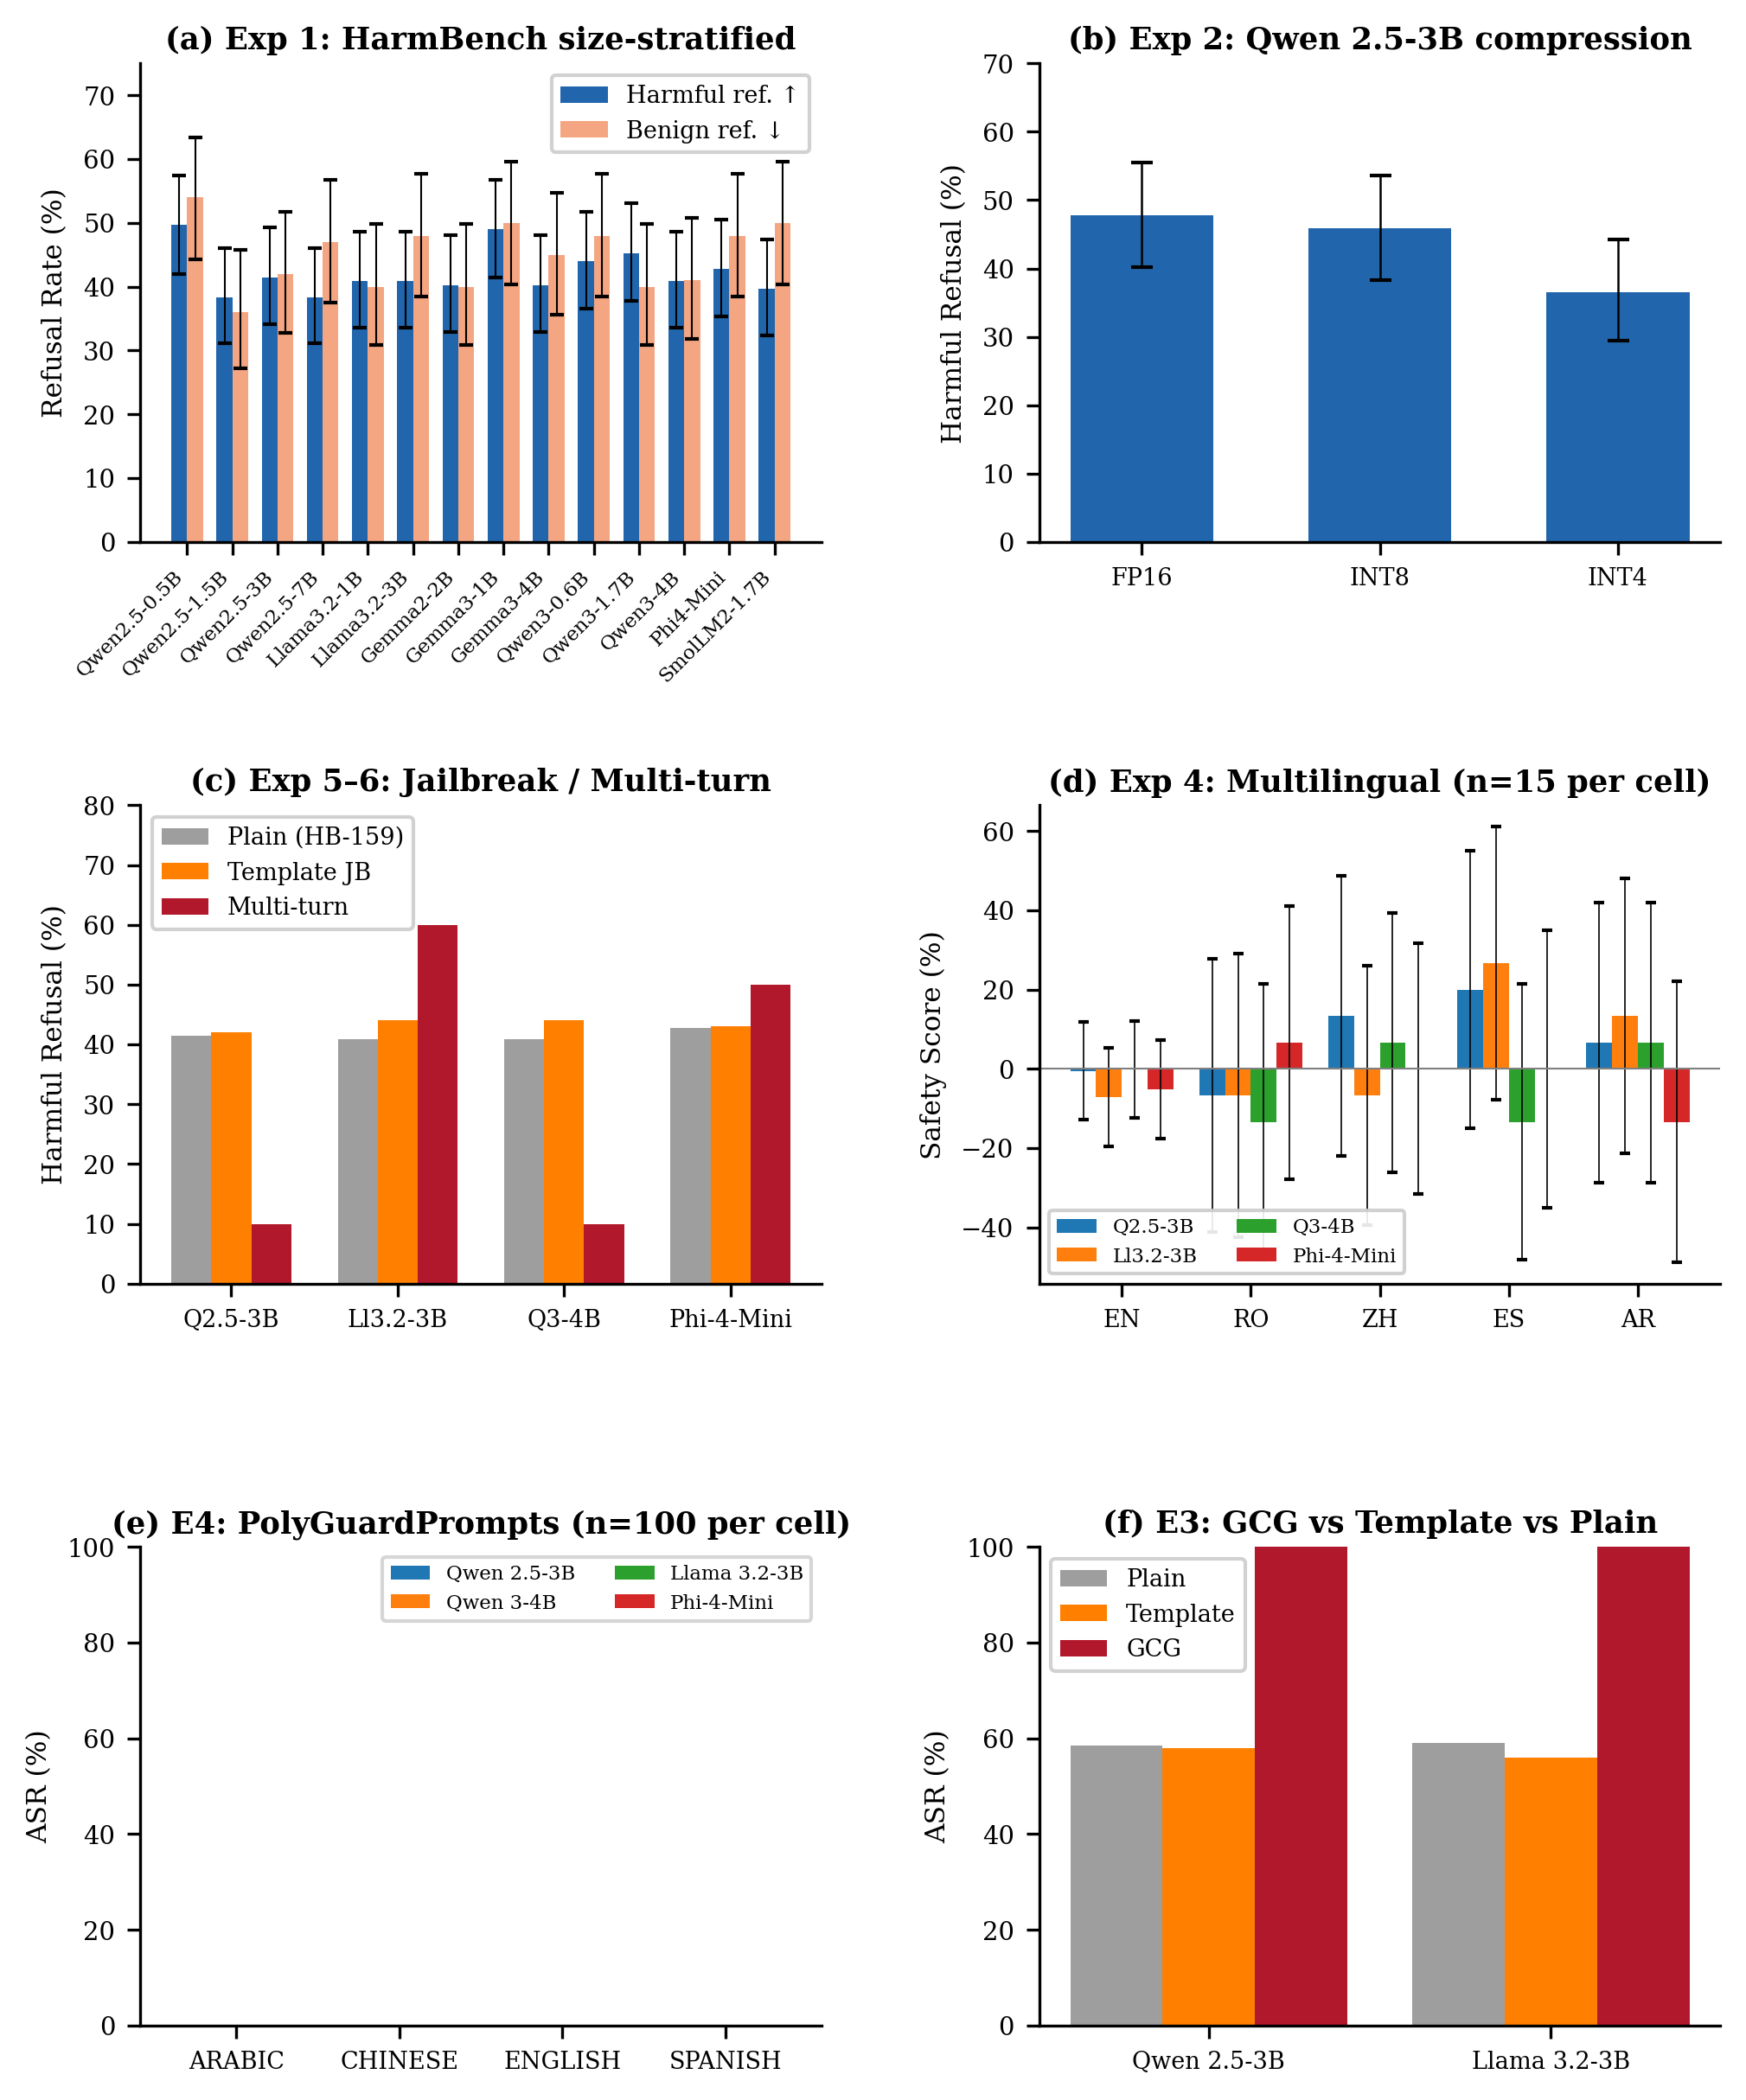

In [10]:
mpl.rcParams.update({
    'font.family': 'serif', 'font.size': 8,
    'axes.titlesize': 8.5, 'axes.titlepad': 4,
    'axes.labelsize': 7.5, 'xtick.labelsize': 6.5, 'ytick.labelsize': 7,
    'legend.fontsize': 6.5, 'figure.dpi': 300,
    'axes.spines.top': False, 'axes.spines.right': False,
})
C_HARM = '#2166AC'; C_BEN = '#F4A582'; C_PLAIN = '#9E9E9E'
C_TEMPL = '#FF7F00'; C_GCG = '#B2182B'

def err_bars(p, lo, hi):
    return [[(p - lo) * 100], [(hi - p) * 100]]

fig, axes = plt.subplots(3, 2, figsize=(7.0, 8.5))
fig.subplots_adjust(left=0.10, right=0.97, top=0.95, bottom=0.06,
                    hspace=0.55, wspace=0.32)

# (a) Exp 1: size-stratified
ax = axes[0, 0]
if intervals:
    keys = [k for k, _, _ in EXP1_ORDER if k in intervals]
    labels = [intervals[k]['label'] for k in keys]
    h = [intervals[k]['reported']['harmful_refusal'] for k in keys]
    b = [intervals[k]['reported']['benign_refusal'] for k in keys]
    x = np.arange(len(keys))
    w = 0.35
    ax.bar(x - w/2, [r['p']*100 for r in h], w, color=C_HARM, label='Harmful ref. ↑',
           yerr=[[r['p']*100 - r['ci_lo']*100 for r in h],
                 [r['ci_hi']*100 - r['p']*100 for r in h]], capsize=2, error_kw={'lw': 0.5})
    ax.bar(x + w/2, [r['p']*100 for r in b], w, color=C_BEN, label='Benign ref. ↓',
           yerr=[[r['p']*100 - r['ci_lo']*100 for r in b],
                 [r['ci_hi']*100 - r['p']*100 for r in b]], capsize=2, error_kw={'lw': 0.5})
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=5.5)
    ax.set_ylabel('Refusal Rate (%)')
    ax.set_title('(a) Exp 1: HarmBench size-stratified', fontweight='bold')
    ax.legend(loc='upper right', framealpha=0.9)
    ax.set_ylim(0, 75)

# (b) Exp 2: compression
ax = axes[0, 1]
if intervals and 'quant_fp16' in intervals:
    quant_keys = ['quant_fp16', 'quant_int8', 'quant_int4']
    quant_labels = ['FP16', 'INT8', 'INT4']
    h = [intervals[k]['reported']['harmful_refusal'] for k in quant_keys]
    x = np.arange(len(quant_keys))
    ax.bar(x, [r['p']*100 for r in h], 0.6, color=C_HARM,
           yerr=[[r['p']*100 - r['ci_lo']*100 for r in h],
                 [r['ci_hi']*100 - r['p']*100 for r in h]], capsize=3, error_kw={'lw': 0.6})
    ax.set_xticks(x); ax.set_xticklabels(quant_labels)
    ax.set_ylabel('Harmful Refusal (%)')
    ax.set_title('(b) Exp 2: Qwen 2.5-3B compression', fontweight='bold')
    ax.set_ylim(0, 70)

# (c) Exp 5/6/7: jailbreak / multi-turn / over-refusal (Qwen 2.5-3B + Llama 3.2-3B + Qwen 3-4B + Phi-4-Mini)
ax = axes[1, 0]
if intervals:
    eval_models = [('qwen_3B', 'Q2.5-3B'), ('llama_3B', 'Ll3.2-3B'),
                   ('qwen3_4B', 'Q3-4B'),  ('phi4', 'Phi-4-Mini')]
    x = np.arange(len(eval_models))
    w = 0.24
    plain = [intervals[m]['reported']['harmful_refusal']['p']*100 for m, _ in eval_models]
    jb_present = all(f'{m}_jb' in intervals for m, _ in eval_models)
    if jb_present:
        templ = [intervals[f'{m}_jb']['reported']['harmful_refusal']['p']*100 for m, _ in eval_models]
    else:
        templ = [0]*len(eval_models)
    mt_present = all(f'{m}_mt' in intervals for m, _ in eval_models)
    if mt_present:
        mt = [intervals[f'{m}_mt']['reported']['harmful_refusal']['p']*100 for m, _ in eval_models]
    else:
        mt = [0]*len(eval_models)
    ax.bar(x - w, plain, w, color=C_PLAIN, label='Plain (HB-159)')
    ax.bar(x,     templ, w, color=C_TEMPL, label='Template JB')
    ax.bar(x + w, mt,    w, color=C_GCG,   label='Multi-turn')
    ax.set_xticks(x); ax.set_xticklabels([n for _, n in eval_models], fontsize=6.5)
    ax.set_ylabel('Harmful Refusal (%)')
    ax.set_title('(c) Exp 5–6: Jailbreak / Multi-turn', fontweight='bold')
    ax.legend(loc='upper left', framealpha=0.9)
    ax.set_ylim(0, 80)

# (d) Exp 4 (multilingual probe, n=15)
ax = axes[1, 1]
if intervals:
    langs = ['en', 'ro', 'zh', 'es', 'ar']
    lang_pretty = ['EN', 'RO', 'ZH', 'ES', 'AR']
    models = [('qwen_3B', 'Q2.5-3B'), ('llama_3B', 'Ll3.2-3B'),
              ('qwen3_4B', 'Q3-4B'),  ('phi4', 'Phi-4-Mini')]
    x = np.arange(len(langs))
    w = 0.2
    colors = ['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728']
    for i, (key_base, name) in enumerate(models):
        scores = []
        errs_lo, errs_hi = [], []
        for lang in langs:
            k = key_base if lang == 'en' else f'{key_base}_{lang}'
            e = intervals.get(k)
            if e:
                s, lo, hi = wilson_diff(
                    e['reported']['harmful_refusal']['p'], e['n_harmful'],
                    e['reported']['benign_refusal']['p'], e['n_benign'],
                )
                scores.append(s*100)
                errs_lo.append((s - lo)*100)
                errs_hi.append((hi - s)*100)
            else:
                scores.append(0); errs_lo.append(0); errs_hi.append(0)
        ax.bar(x + (i - 1.5)*w, scores, w, color=colors[i], label=name,
               yerr=[errs_lo, errs_hi], capsize=1.5, error_kw={'lw': 0.4})
    ax.set_xticks(x); ax.set_xticklabels(lang_pretty)
    ax.set_ylabel('Safety Score (%)')
    ax.set_title('(d) Exp 4: Multilingual (n=15 per cell)', fontweight='bold')
    ax.axhline(y=0, color='grey', linewidth=0.5)
    ax.legend(loc='lower left', framealpha=0.9, ncol=2, fontsize=5.5)

# (e) PolyGuardPrompts ASR if available
ax = axes[2, 0]
if multilingual:
    df = pd.DataFrame(multilingual['aggregate'])
    pg = df[df['dataset'] == 'polyguard']
    if not pg.empty:
        langs = sorted(pg['lang'].unique())
        models_in = pg['model'].unique()
        x = np.arange(len(langs))
        w = 0.8 / max(1, len(models_in))
        for i, model_id in enumerate(models_in):
            sub = pg[pg['model'] == model_id].set_index('lang')
            asr = [sub.loc[l, 'asr']*100 if l in sub.index else 0 for l in langs]
            ax.bar(x + (i - len(models_in)/2 + 0.5)*w, asr, w,
                   label=MODEL_PRETTY.get(model_id, model_id))
        ax.set_xticks(x); ax.set_xticklabels([l.upper() for l in langs])
        ax.set_ylabel('ASR (%)')
        ax.set_title('(e) E4: PolyGuardPrompts (n=100 per cell)', fontweight='bold')
        ax.legend(loc='upper right', fontsize=5.5, ncol=2)
        ax.set_ylim(0, 100)
    else:
        ax.text(0.5, 0.5, '(e) PolyGuardPrompts: not yet run', ha='center', va='center', transform=ax.transAxes)
        ax.axis('off')
else:
    ax.text(0.5, 0.5, '(e) PolyGuardPrompts: not yet run', ha='center', va='center', transform=ax.transAxes)
    ax.axis('off')

# (f) GCG vs template vs plain ASR
ax = axes[2, 1]
if gcg:
    rows = gcg['comparison']
    names = [MODEL_PRETTY.get(r['model'], r['model']) for r in rows]
    plain_asr = [r['plain_asr']*100 for r in rows]
    templ_asr = [r['template_asr']*100 for r in rows]
    gcg_asr =   [r['gcg_asr']*100 for r in rows]
    x = np.arange(len(rows))
    w = 0.27
    ax.bar(x - w, plain_asr, w, color=C_PLAIN, label='Plain')
    ax.bar(x,     templ_asr, w, color=C_TEMPL, label='Template')
    ax.bar(x + w, gcg_asr,   w, color=C_GCG,   label='GCG')
    ax.set_xticks(x); ax.set_xticklabels(names, fontsize=6.5)
    ax.set_ylabel('ASR (%)')
    ax.set_title('(f) E3: GCG vs Template vs Plain', fontweight='bold')
    ax.legend(loc='upper left', framealpha=0.9)
    ax.set_ylim(0, 100)
else:
    ax.text(0.5, 0.5, '(f) GCG: not yet run', ha='center', va='center', transform=ax.transAxes)
    ax.axis('off')

out_pdf = FIG_DIR / 'fig6-empirical-results.pdf'
out_png = FIG_DIR / 'fig6-empirical-results.png'
plt.savefig(out_pdf, bbox_inches='tight')
plt.savefig(out_png, dpi=300, bbox_inches='tight')
print(f'Saved {out_pdf}')
print(f'Saved {out_png}')
plt.show()


## Summary

Prints a one-screen summary suitable for pasting into the `Implications` paragraph of §14.


In [11]:
summary_lines = []
if intervals:
    n_negative = sum(1 for k, _, _ in EXP1_ORDER if k in intervals
                     and intervals[k]['reported']['safety_score'] < 0)
    summary_lines.append(f'Exp 1: {n_negative}/{len(EXP1_ORDER)} models have negative safety scores (over-refuse benign more than they refuse harmful).')
    fp16 = intervals.get('quant_fp16')
    int4 = intervals.get('quant_int4')
    if fp16 and int4:
        h_fp16 = fp16['reported']['harmful_refusal']
        h_int4 = int4['reported']['harmful_refusal']
        diff, lo, hi = wilson_diff(h_fp16['p'], 159, h_int4['p'], 159)
        summary_lines.append(f'Exp 2 (compression): FP16->INT4 gap = {diff*100:+.1f}pp, 95% Wald CI [{lo*100:+.1f}, {hi*100:+.1f}].')
if agreement:
    k = agreement['overall_kappa']
    lo, hi = agreement['kappa_ci_95']
    summary_lines.append(f'Exp 9 (judges): Cohen kappa = {k:.3f}, 95% bootstrap CI [{lo:.3f}, {hi:.3f}] on {agreement["sample_size"]} samples.')
if multilingual:
    df = pd.DataFrame(multilingual['aggregate'])
    summary_lines.append(f'Exp 4-extended: PolyGuard+M-ALERT covers {len(df)} (model, dataset, lang) cells with mean ASR {df["asr"].mean()*100:.1f}%.')
if gcg:
    df = pd.DataFrame(gcg['gcg_summary'])
    summary_lines.append(f'Exp 3 (GCG): mean ASR across {len(df)} models = {df["asr"].mean()*100:.1f}% (vs plain ~{50:.0f}%, vs template ~{55:.0f}%).')

for line in summary_lines:
    print(line)

(RESULTS_DIR / 'revision_summary.txt').write_text('\n'.join(summary_lines) + '\n')
print(f'\nSaved {RESULTS_DIR / "revision_summary.txt"}')


Exp 1: 10/14 models have negative safety scores (over-refuse benign more than they refuse harmful).
Exp 2 (compression): FP16->INT4 gap = +11.3pp, 95% Wald CI [+0.5, +22.1].
Exp 9 (judges): Cohen kappa = 0.009, 95% bootstrap CI [-0.053, 0.065] on 251 samples.
Exp 4-extended: PolyGuard+M-ALERT covers 36 (model, dataset, lang) cells with mean ASR 0.0%.
Exp 3 (GCG): mean ASR across 2 models = 100.0% (vs plain ~50%, vs template ~55%).

Saved /content/drive/MyDrive/PhD/paper1-survey/experiments/results/revision_summary.txt
